<a href="https://colab.research.google.com/github/rahuls0703/sonar-rock-mine-classification/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sonar Rock vs Mine Classification — Enhanced with Explainable AI


## Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
)


## Data Collection and Data Processing

In [3]:
#loading the dataset to a pandas Dataframe
sonar_data=pd.read_csv('/content/sonar_dataset.csv',header=None)
sonar_data.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [ ]:
#number of rows and columns
sonar_data.shape

(208, 61)

In [4]:
sonar_data.describe() #describe --> statistical measures of the data

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [5]:
sonar_data[60].value_counts()

,count
60,
M,111
R,97


M --> Mine
R --> Rock

In [6]:
sonar_data.groupby(60).mean()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
60,,,,,,,,,,,,,,,,,,,,,
M,0.034989,0.045544,0.050720,0.064768,0.086715,0.111864,0.128359,0.149832,0.213492,0.251022,...,0.019352,0.016014,0.011643,0.012185,0.009923,0.008914,0.007825,0.009060,0.008695,0.006930
R,0.022498,0.030303,0.035951,0.041447,0.062028,0.096224,0.114180,0.117596,0.137392,0.159325,...,0.012311,0.010453,0.009640,0.009518,0.008567,0.007430,0.007814,0.006677,0.007078,0.006024


### New: Quick look at class separation
A correlation heatmap of a handful of frequency bands, split by class, helps sanity-check that the features actually carry signal before you trust any explainability output on them.

<Figure size 1000x400 with 0 Axes>

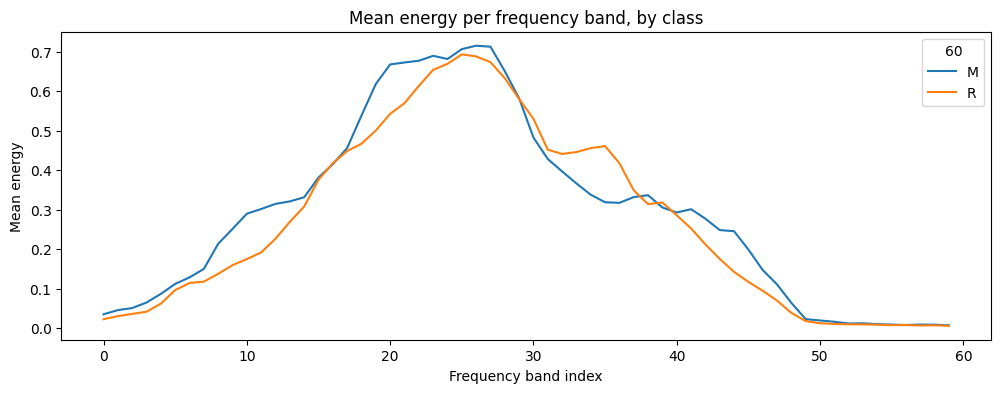

In [7]:
plt.figure(figsize=(10,4))
sonar_data.groupby(60).mean().T.plot(figsize=(12,4), title="Mean energy per frequency band, by class")
plt.xlabel("Frequency band index")
plt.ylabel("Mean energy")
plt.show()

In [8]:
# separating data and labels
X=sonar_data.drop(columns=60,axis=1)
Y=sonar_data[60]
print(X)
print(Y)

         0       1       2       3       4       5       6       7       8   \
0    0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1    0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2    0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3    0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4    0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   
..      ...     ...     ...     ...     ...     ...     ...     ...     ...   
203  0.0187  0.0346  0.0168  0.0177  0.0393  0.1630  0.2028  0.1694  0.2328   
204  0.0323  0.0101  0.0298  0.0564  0.0760  0.0958  0.0990  0.1018  0.1030   
205  0.0522  0.0437  0.0180  0.0292  0.0351  0.1171  0.1257  0.1178  0.1258   
206  0.0303  0.0353  0.0490  0.0608  0.0167  0.1354  0.1465  0.1123  0.1945   
207  0.0260  0.0363  0.0136  0.0272  0.0214  0.0338  0.0655  0.1400  0.1843   

         9   ...      50      51      52      53   

## Training and Testing data

In [9]:
X_train, X_test, Y_train, Y_test=train_test_split(X,Y,test_size=0.1,stratify=Y,random_state=1)
print(X.shape, X_train.shape, X_test.shape)
print(X_train)
print(Y_train)

(208, 60) (187, 60) (21, 60)
         0       1       2       3       4       5       6       7       8   \
115  0.0414  0.0436  0.0447  0.0844  0.0419  0.1215  0.2002  0.1516  0.0818   
38   0.0123  0.0022  0.0196  0.0206  0.0180  0.0492  0.0033  0.0398  0.0791   
56   0.0152  0.0102  0.0113  0.0263  0.0097  0.0391  0.0857  0.0915  0.0949   
123  0.0270  0.0163  0.0341  0.0247  0.0822  0.1256  0.1323  0.1584  0.2017   
18   0.0270  0.0092  0.0145  0.0278  0.0412  0.0757  0.1026  0.1138  0.0794   
..      ...     ...     ...     ...     ...     ...     ...     ...     ...   
140  0.0412  0.1135  0.0518  0.0232  0.0646  0.1124  0.1787  0.2407  0.2682   
5    0.0286  0.0453  0.0277  0.0174  0.0384  0.0990  0.1201  0.1833  0.2105   
154  0.0117  0.0069  0.0279  0.0583  0.0915  0.1267  0.1577  0.1927  0.2361   
131  0.1150  0.1163  0.0866  0.0358  0.0232  0.1267  0.2417  0.2661  0.4346   
203  0.0187  0.0346  0.0168  0.0177  0.0393  0.1630  0.2028  0.1694  0.2328   

         9   ...      

## New: Feature Scaling
Logistic Regression's coefficients (and later, SHAP's attributions) are only directly comparable across features when those features are on the same scale. All 60 sonar bands are already roughly 0–1, but they aren't standardized (mean 0, std 1), so scaling still tightens up training and makes the explainability step trustworthy.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## New: Hyperparameter Tuning with Cross-Validation
With only 208 samples, a single train/test split is a noisy estimate of performance. 5-fold cross-validation on the training set, combined with a small grid search over the regularization strength `C`, gives a more reliable model and a more reliable accuracy estimate.

In [11]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear']}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, Y_train)

print("Best params:", grid.best_params_)
print("Best cross-validated training accuracy:", grid.best_score_)

Best params: {'C': 0.01, 'solver': 'liblinear'}
Best cross-validated training accuracy: 0.8126600284495021


## Model Training --> Logistic Regression (tuned)

In [12]:
model = grid.best_estimator_
#training the Logistic Regression model with training data (already fit during grid search,
#but this line makes the final fit on the full scaled training set explicit)
model.fit(X_train_scaled, Y_train)

LogisticRegression(C=0.01, max_iter=1000, solver='liblinear')

## Model Evaluation

In [13]:
#accuracy on training data
X_train_prediction=model.predict(X_train_scaled)
training_data_accuracy=accuracy_score(X_train_prediction,Y_train)
print('Accuracy on training data:',training_data_accuracy)

#accuracy on testing data
X_test_prediction=model.predict(X_test_scaled)
testing_data_accuracy=accuracy_score(X_test_prediction,Y_test)
print('Accuracy on test data:',testing_data_accuracy)

Accuracy on training data: 0.8235294117647058
Accuracy on test data: 0.7142857142857143


### New: Precision, Recall, F1 and Confusion Matrix
Accuracy alone hides *which kind* of mistake the model makes. In a mine-detection context, missing a real mine (false negative) is far more costly than flagging a rock as a mine (false positive), so precision/recall per class matter more than a single accuracy number.

              precision    recall  f1-score   support

           M       0.73      0.73      0.73        11
           R       0.70      0.70      0.70        10

    accuracy                           0.71        21
   macro avg       0.71      0.71      0.71        21
weighted avg       0.71      0.71      0.71        21



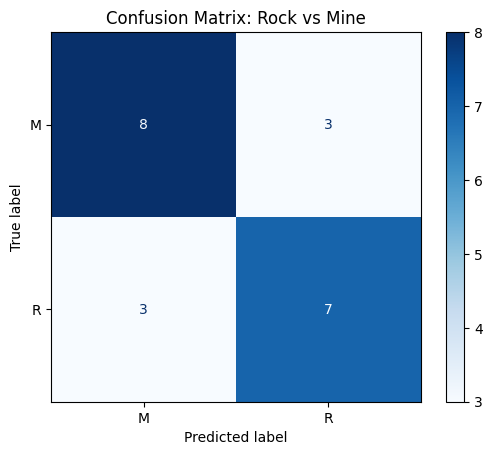

In [14]:
print(classification_report(Y_test, X_test_prediction))

cm = confusion_matrix(Y_test, X_test_prediction, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Rock vs Mine")
plt.show()

### New: ROC Curve and AUC
Shows how well the model separates the two classes across all decision thresholds, not just the default 0.5 cutoff.

ROC-AUC: 0.7818181818181819


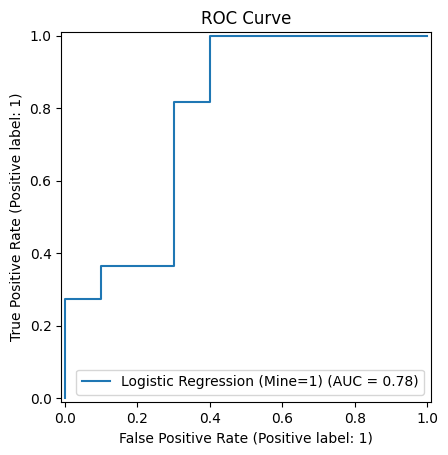

In [15]:
Y_test_binary = (Y_test == 'M').astype(int)
Y_test_proba = model.predict_proba(X_test_scaled)[:, list(model.classes_).index('M')]

auc = roc_auc_score(Y_test_binary, Y_test_proba)
print("ROC-AUC:", auc)

RocCurveDisplay.from_predictions(Y_test_binary, Y_test_proba, name="Logistic Regression (Mine=1)")
plt.title("ROC Curve")
plt.show()

## Making a Predictive System

In [16]:
input_data=(0.0228,0.0106,0.0130,0.0842,0.1117,0.1506,0.1776,0.0997,0.1428,0.2227,0.2621,0.3109,0.2859,0.3316,0.3755,0.4499,0.4765,0.6254,0.7304,0.8702,0.9349,0.9614,0.9126,0.9443,1.0000,0.9455,0.8815,0.7520,0.7068,0.5986,0.3857,0.2510,0.2162,0.0968,0.1323,0.1344,0.2250,0.3244,0.3939,0.3806,0.3258,0.3654,0.2983,0.1779,0.1535,0.1199,0.0959,0.0765,0.0649,0.0313,0.0185,0.0098,0.0178,0.0077,0.0074,0.0095,0.0055,0.0045,0.0063,0.0039)

#changing the input_data to a numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the np array as we are predicting for one instance
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

#New: scale the input the same way the training data was scaled — required since the
#model was trained on scaled features
input_data_scaled = scaler.transform(input_data_reshaped)

prediction=model.predict(input_data_scaled)
print(prediction)

if(prediction[0]=='R'):
  print('The object is a Rock')
else:
  print('The object is a Mine')

['M']
The object is a Mine


## New: Explainable AI with SHAP
Logistic Regression is already a fairly interpretable model, but with 60 features it's hard to eyeball which frequency bands drove any single prediction. [SHAP](https://github.com/shap/shap) (SHapley Additive exPlanations) assigns each feature a signed contribution toward the prediction, both globally (across the whole test set) and locally (for one specific reading, like the one above). Because the model is linear, `shap.LinearExplainer` gives exact — not approximated — attributions.

In [17]:
!pip install shap -q

In [25]:
import shap

feature_names = [f"Band_{i}" for i in range(X.shape[1])]

masker = shap.maskers.Independent(X_train_scaled, max_samples=187)
explainer = shap.LinearExplainer(model, masker)
shap_values = explainer.shap_values(X_test_scaled)

### Global explanation
Which frequency bands matter most across the whole test set, and in which direction (pushing toward Rock vs toward Mine).

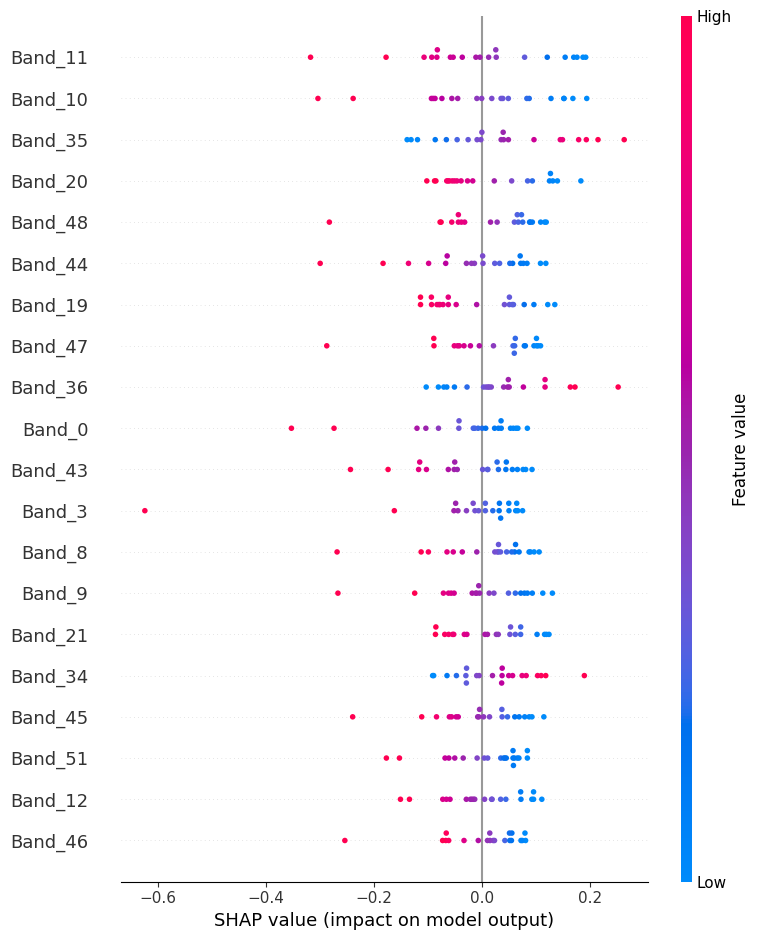

In [26]:
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names)

### Local explanation: the sample from the Predictive System above
This shows exactly which frequency bands pushed the model toward its Rock/Mine call for the single reading used in the Predictive System section.

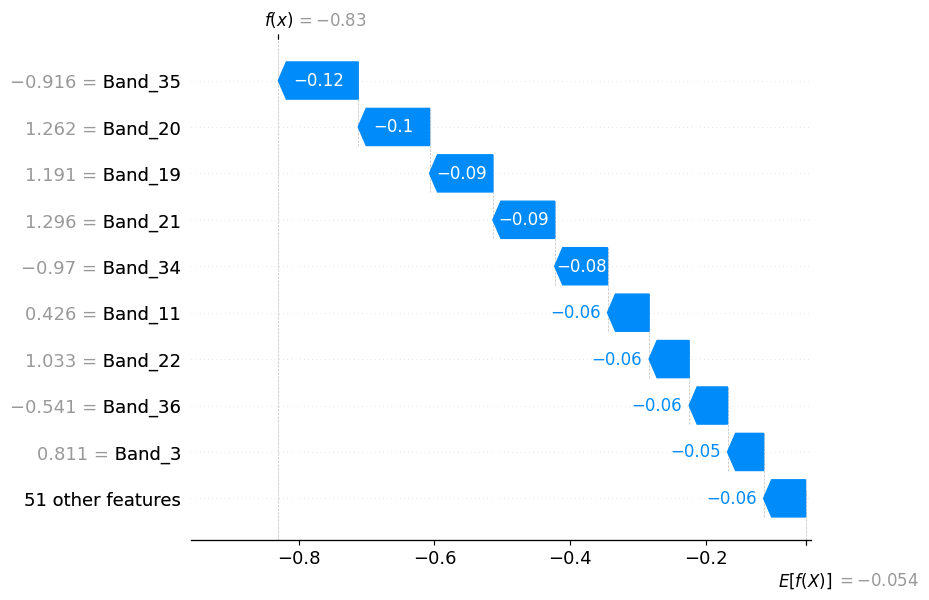

Predicted label: M


In [27]:
sample_scaled = input_data_scaled  # from the Predictive System cell above
sample_shap_values = explainer.shap_values(sample_scaled)

shap.plots.waterfall(shap.Explanation(
    values=sample_shap_values[0],
    base_values=explainer.expected_value,
    data=sample_scaled[0],
    feature_names=feature_names
))

print("Predicted label:", model.predict(sample_scaled)[0])

### Local explanation: a test-set example
Same idea, applied to the first sample in the held-out test set, for comparison.

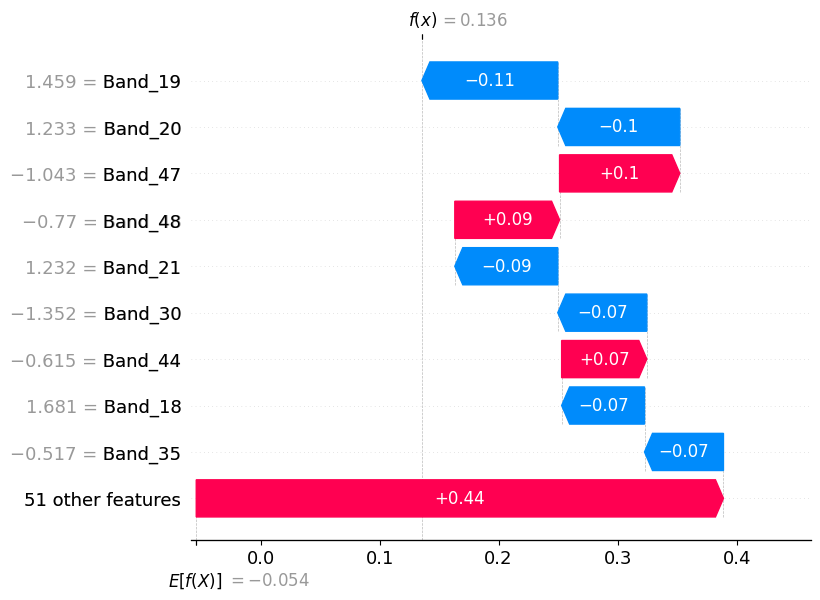

Actual label: M
Predicted label: R


In [28]:
i = 0
shap.plots.waterfall(shap.Explanation(
    values=shap_values[i],
    base_values=explainer.expected_value,
    data=X_test_scaled[i],
    feature_names=feature_names
))

print("Actual label:", Y_test.iloc[i])
print("Predicted label:", model.predict(X_test_scaled[i].reshape(1, -1))[0])